In [1]:
!pip install shap

In [2]:
import shap
import joblib
import pandas as pd

model = joblib.load("linear_regression_model.pkl")

df = pd.read_csv("dashboard_data.csv")

In [3]:
X = df.drop([
    'ATM_ID',
    'Predicted_Demand',
    'Risk_Level',
    'Priority_Rank'
], axis=1)

explainer = shap.Explainer(model, X)

shap_values = explainer(X)

Background dataset has 5658 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5658 when initializing the masker.


ValueError: shapes (26,) and (3,) not aligned: 26 (dim 0) != 3 (dim 0)

In [6]:
print(X.columns)
print(len(X.columns))
print(model.n_features_in_)

Index(['Current_Cash_Level', 'Required_Cash', 'Recommended_Refill'], dtype='object')
3
26


In [7]:
df_encoded = pd.read_csv("dashboard_data.csv")

X = df_encoded.drop([
    'ATM_ID',
    'Predicted_Demand',
    'Risk_Level',
    'Priority_Rank'
], axis=1)

print(X.shape)

(5658, 3)


In [8]:
print("Model expects:", model.n_features_in_)
print("Data has:", X.shape[1])

Model expects: 26
Data has: 3


In [9]:
import shap

explainer = shap.LinearExplainer(model, X)

shap_values = explainer.shap_values(X)

Background dataset has 5658 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5658 when initializing the masker.


ValueError: shapes (26,) and (3,) not aligned: 26 (dim 0) != 3 (dim 0)

In [10]:
print(model.n_features_in_)
print(X.shape)
print(X.columns.tolist())

26
(5658, 3)
['Current_Cash_Level', 'Required_Cash', 'Recommended_Refill']


In [11]:
import pandas as pd
import joblib
import shap

# Load model
model = joblib.load("linear_regression_model.pkl")

# Load encoded dataset
df = pd.read_csv("atm_encoded_dataset.csv")

# Remove columns NOT used during training
X = df.drop(columns=[
    'ATM_ID',
    'Predicted_Demand',
    'Risk_Level',
    'Priority_Rank',
    'Safety_Buffer_Percentage',
    'Current_Cash_Level',
    'Cash_Shortage',
    'Safety_Buffer_Amount',
    'Required_Cash',
    'Recommended_Refill'
], errors='ignore')

print("Model expects:", model.n_features_in_)
print("Data has:", X.shape[1])

Model expects: 26
Data has: 28


In [12]:
print(df.columns)
print(len(df.columns))

Index(['ATM_ID', 'Date', 'Total_Withdrawals', 'Total_Deposits', 'Holiday_Flag',
       'Special_Event_Flag', 'Previous_Day_Cash_Level',
       'Nearby_Competitor_ATMs', 'Cash_Demand_Next_Day', 'Year', 'Month',
       'Day', 'Quarter', 'Day_of_Week_Monday', 'Day_of_Week_Saturday',
       'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday',
       'Day_of_Week_Wednesday', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Location_Type_Gas Station', 'Location_Type_Mall',
       'Location_Type_Standalone', 'Location_Type_Supermarket',
       'Weather_Condition_Cloudy', 'Weather_Condition_Rainy',
       'Weather_Condition_Snowy'],
      dtype='object')
29


In [13]:
X = df.drop(columns=[
    'ATM_ID',
    'Date',                    # remove
    'Cash_Demand_Next_Day',    # remove target column

    'Predicted_Demand',
    'Risk_Level',
    'Priority_Rank',
    'Safety_Buffer_Percentage',
    'Current_Cash_Level',
    'Cash_Shortage',
    'Safety_Buffer_Amount',
    'Required_Cash',
    'Recommended_Refill'
], errors='ignore')

In [14]:
print("Model expects:", model.n_features_in_)
print("Data has:", X.shape[1])

Model expects: 26
Data has: 26


In [15]:
import shap

explainer = shap.LinearExplainer(model, X)
shap_values = explainer.shap_values(X)

Background dataset has 5658 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5658 when initializing the masker.


In [16]:
print(X.columns.tolist())

['Total_Withdrawals', 'Total_Deposits', 'Holiday_Flag', 'Special_Event_Flag', 'Previous_Day_Cash_Level', 'Nearby_Competitor_ATMs', 'Year', 'Month', 'Day', 'Quarter', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Location_Type_Gas Station', 'Location_Type_Mall', 'Location_Type_Standalone', 'Location_Type_Supermarket', 'Weather_Condition_Cloudy', 'Weather_Condition_Rainy', 'Weather_Condition_Snowy']


TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

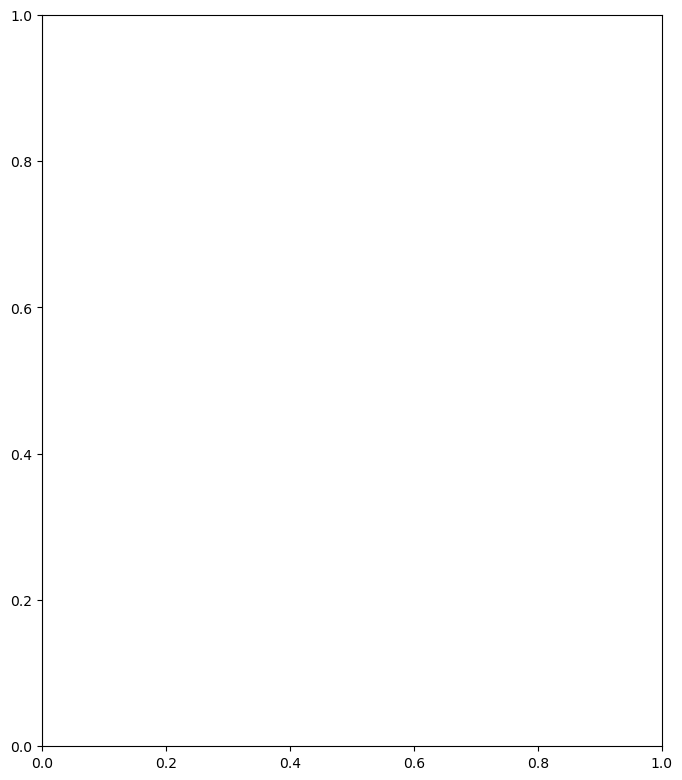

In [18]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.show()

In [19]:
print(X.dtypes)

Total_Withdrawals            int64
Total_Deposits               int64
Holiday_Flag                 int64
Special_Event_Flag           int64
Previous_Day_Cash_Level      int64
Nearby_Competitor_ATMs       int64
Year                         int64
Month                        int64
Day                          int64
Quarter                      int64
Day_of_Week_Monday            bool
Day_of_Week_Saturday          bool
Day_of_Week_Sunday            bool
Day_of_Week_Thursday          bool
Day_of_Week_Tuesday           bool
Day_of_Week_Wednesday         bool
Time_of_Day_Evening           bool
Time_of_Day_Morning           bool
Time_of_Day_Night             bool
Location_Type_Gas Station     bool
Location_Type_Mall            bool
Location_Type_Standalone      bool
Location_Type_Supermarket     bool
Weather_Condition_Cloudy      bool
Weather_Condition_Rainy       bool
Weather_Condition_Snowy       bool
dtype: object


In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Total_Withdrawals          5658 non-null   int64
 1   Total_Deposits             5658 non-null   int64
 2   Holiday_Flag               5658 non-null   int64
 3   Special_Event_Flag         5658 non-null   int64
 4   Previous_Day_Cash_Level    5658 non-null   int64
 5   Nearby_Competitor_ATMs     5658 non-null   int64
 6   Year                       5658 non-null   int64
 7   Month                      5658 non-null   int64
 8   Day                        5658 non-null   int64
 9   Quarter                    5658 non-null   int64
 10  Day_of_Week_Monday         5658 non-null   bool 
 11  Day_of_Week_Saturday       5658 non-null   bool 
 12  Day_of_Week_Sunday         5658 non-null   bool 
 13  Day_of_Week_Thursday       5658 non-null   bool 
 14  Day_of_Week_Tuesday     

In [21]:
# Convert boolean columns to integer
bool_cols = X.select_dtypes(include=['bool']).columns

X[bool_cols] = X[bool_cols].astype(int)

print(X.dtypes)

Total_Withdrawals            int64
Total_Deposits               int64
Holiday_Flag                 int64
Special_Event_Flag           int64
Previous_Day_Cash_Level      int64
Nearby_Competitor_ATMs       int64
Year                         int64
Month                        int64
Day                          int64
Quarter                      int64
Day_of_Week_Monday           int64
Day_of_Week_Saturday         int64
Day_of_Week_Sunday           int64
Day_of_Week_Thursday         int64
Day_of_Week_Tuesday          int64
Day_of_Week_Wednesday        int64
Time_of_Day_Evening          int64
Time_of_Day_Morning          int64
Time_of_Day_Night            int64
Location_Type_Gas Station    int64
Location_Type_Mall           int64
Location_Type_Standalone     int64
Location_Type_Supermarket    int64
Weather_Condition_Cloudy     int64
Weather_Condition_Rainy      int64
Weather_Condition_Snowy      int64
dtype: object


In [22]:
import shap

explainer = shap.LinearExplainer(model, X)

shap_values = explainer.shap_values(X)

Background dataset has 5658 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5658 when initializing the masker.


In [23]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(5658, 26)


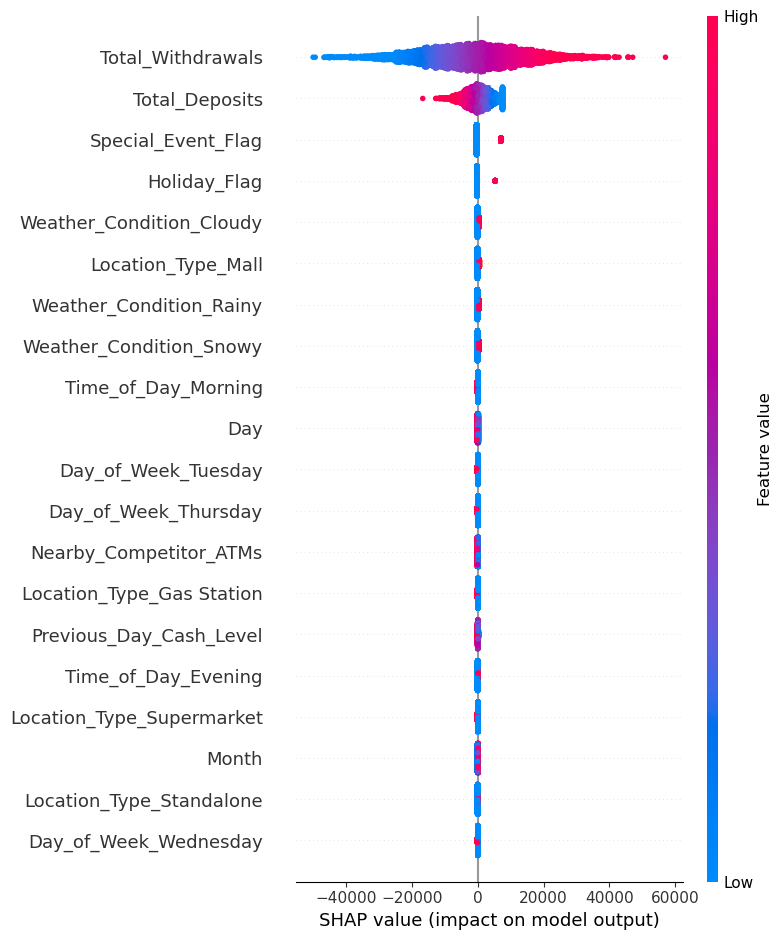

In [24]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X)

In [25]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.close()